# Week 5 - Modern CNNs, Transfer Learning, and Ensembles

Week 4 introduced the standard PyTorch image-classification workflow and compared classic CNNs through VGG. This week moves into supervised CNN classifiers that changed how deeper networks are built, adapted, and combined.

The goals are:

1. Understand why Inception modules use parallel branches and bottleneck convolutions.
2. Understand why residual connections make very deep CNNs trainable.
3. Train and evaluate stronger CNN classifiers with reusable PyTorch code.
4. Use ImageNet-pretrained CNNs for feature extraction and fine-tuning.
5. Know which modern CNN families are still worth discussing in 2026, without switching to vision transformers.
6. Combine classifiers with soft-voting ensembles and snapshot ensembles.

This notebook assumes the same Imagenette folder layout used in Week 4:

```text
../../datasets/imagenette2/train/class_name/image.jpg
../../datasets/imagenette2/val/class_name/image.jpg
```


In [1]:
# Core Python utilities
from pathlib import Path
from copy import deepcopy
import math
import random

# PyTorch and torchvision tools for supervised image classification
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms

# Plotting and optional evaluation utilities
import matplotlib.pyplot as plt

try:
    from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

# Reproducibility: this is a practical default, not a mathematical guarantee.
torch.manual_seed(0)
random.seed(0)

# Device selection: prefer GPU acceleration when it is available.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# CUDA can use pinned memory to speed CPU-to-GPU batch transfer.
pin_memory = device.type == "cuda"
print(f"Using device: {device}")


Using device: cuda


## Dataset and Transforms

For this week, we can use `torchvision.datasets.ImageFolder` because Imagenette already follows the standard folder-per-class format. That is a useful best practice: use a stable library dataset implementation when your data layout matches it, and write a custom `Dataset` only when the data format really requires it.

The ImageNet normalization constants are especially important for transfer learning because the pretrained weights were trained with ImageNet-style preprocessing.


In [2]:
# Dataset locations: each split contains one subfolder per class.
DATA_ROOT = Path("../../datasets/imagenette2")
TRAIN_ROOT = DATA_ROOT / "train"
VAL_ROOT = DATA_ROOT / "val"

# Shared image and loading settings for fair model comparisons.
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

# ImageNet normalization is appropriate for pretrained CNNs.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms include augmentation to reduce overfitting.
training_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation transforms are deterministic so metrics are comparable.
validation_transforms = transforms.Compose([
    transforms.Resize(size=256),
    transforms.CenterCrop(size=IMAGE_SIZE),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# ImageFolder converts class subfolders into integer labels automatically.
training_dataset = datasets.ImageFolder(root=TRAIN_ROOT, transform=training_transforms)
validation_dataset = datasets.ImageFolder(root=VAL_ROOT, transform=validation_transforms)

number_of_classes = len(training_dataset.classes)
class_names = training_dataset.classes

# DataLoaders create batches and handle shuffling/parallel loading.
training_dataloader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Classes: {class_names}")
print(f"Training examples: {len(training_dataset)}")
print(f"Validation examples: {len(validation_dataset)}")


Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Training examples: 9469
Validation examples: 3925


## Inception: Parallel Paths and Bottlenecks

A VGG-style network mostly asks one question repeatedly: "what happens if we stack more 3 by 3 convolutions?" Inception asks a different question: "what if the model learns, at the same layer, which spatial scale is useful?"

An Inception block uses several branches in parallel. A 1 by 1 branch keeps local channel mixtures cheap. A 3 by 3 branch sees a small neighborhood. A 5 by 5 branch sees a larger neighborhood. A pooling branch preserves a different kind of local summary.

The key efficiency trick is the 1 by 1 bottleneck. A 1 by 1 convolution can reduce channel count before an expensive spatial convolution, so the later 3 by 3 or 5 by 5 operation does less work.


In [3]:
class InceptionBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_1x1,
        reduce_3x3,
        out_3x3,
        reduce_5x5,
        out_5x5,
        pool_projection,
    ):
        super().__init__()

        # Branch 1: cheap 1x1 channel mixing.
        self.branch_1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU(inplace=True),
        )

        # Branch 2: 1x1 bottleneck followed by a 3x3 spatial convolution.
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_3x3, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduce_3x3),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_3x3, out_3x3, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU(inplace=True),
        )

        # Branch 3: 1x1 bottleneck followed by a wider 5x5 convolution.
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(in_channels, reduce_5x5, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduce_5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduce_5x5, out_5x5, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU(inplace=True),
        )

        # Branch 4: pooling preserves a different local summary of the feature map.
        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_projection, kernel_size=1, bias=False),
            nn.BatchNorm2d(pool_projection),
            nn.ReLU(inplace=True),
        )

    def forward(self, input_tensor):
        # Concatenate branch outputs along the channel dimension.
        branches = [
            self.branch_1x1(input_tensor),
            self.branch_3x3(input_tensor),
            self.branch_5x5(input_tensor),
            self.branch_pool(input_tensor),
        ]
        return torch.cat(branches, dim=1)


# Shape check: the spatial size is preserved, but channel count increases.
sample = torch.randn(2, 64, 28, 28)
block = InceptionBlock(64, 32, 48, 64, 8, 16, 16)
output = block(sample)
print(f"Input shape:  {tuple(sample.shape)}")
print(f"Output shape: {tuple(output.shape)}")


Input shape:  (2, 64, 28, 28)
Output shape: (2, 128, 28, 28)


## ResNet: Learn the Residual

Very deep plain CNNs can become hard to optimize. ResNet's idea is to let a block learn a residual correction instead of an entirely new representation.

A residual block computes:

```text
output = F(x) + x
```

If a deeper layer is not useful, the block can learn a near-zero correction and pass information forward through the shortcut. This makes depth easier to optimize and helps gradients move backward through the network.


In [4]:
class BasicResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # Main path: two convolutions learn a residual update F(x).
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        # Shortcut path: identity when shapes match, projection when they do not.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

        self.activation = nn.ReLU(inplace=True)

    def forward(self, input_tensor):
        # ResNet block output: activation(F(x) + shortcut(x)).
        residual = self.shortcut(input_tensor)
        learned_update = self.main_path(input_tensor)
        return self.activation(learned_update + residual)


# Shape check: stride=2 downsamples while the shortcut keeps the addition valid.
sample = torch.randn(2, 64, 56, 56)
block = BasicResidualBlock(64, 128, stride=2)
output = block(sample)
print(f"Input shape:  {tuple(sample.shape)}")
print(f"Output shape: {tuple(output.shape)}")


Input shape:  (2, 64, 56, 56)
Output shape: (2, 128, 28, 28)


## A Reusable Supervised Training Function

The function below keeps the Week 4 training structure but wraps it so we can compare multiple architectures. It includes common 2026 PyTorch practices:

- `AdamW` with weight decay.
- `CrossEntropyLoss` with optional label smoothing.
- Gradient clipping.
- Cosine learning-rate scheduling.
- Best-checkpoint saving.
- A generic output helper for models that may return auxiliary outputs.

Set `number_of_epochs` conservatively while experimenting. These architectures can take time on CPU.


In [5]:
def logits_from_model_output(model_output):
    """Return the main logits from ordinary or auxiliary model outputs."""
    # Some CNNs can return auxiliary outputs; the loss should use the main logits.
    if isinstance(model_output, tuple):
        return model_output[0]
    if hasattr(model_output, "logits"):
        return model_output.logits
    return model_output


def train_classifier(
    model,
    checkpoint_path,
    *,
    number_of_epochs=10,
    learning_rate=3e-4,
    weight_decay=1e-4,
    label_smoothing=0.05,
    train_loader=training_dataloader,
    val_loader=validation_dataloader,
):
    model = model.to(device)
    checkpoint_path = Path(checkpoint_path)

    # Loss, optimizer, and scheduler are shared across architecture experiments.
    loss_function = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=number_of_epochs,
    )

    history = {
        "training_loss": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }
    best_validation_accuracy = 0.0
    best_model_state = None

    for epoch_index in range(number_of_epochs):
        # Training phase: gradients are computed and weights are updated.
        model.train()
        total_training_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = logits_from_model_output(model(images))
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_training_loss += loss.item() * images.size(0)

        scheduler.step()
        average_training_loss = total_training_loss / len(train_loader.dataset)

        # Validation phase: no gradients and no parameter updates.
        model.eval()
        total_validation_loss = 0.0
        number_correct = 0
        number_seen = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = logits_from_model_output(model(images))
                loss = loss_function(logits, labels)

                total_validation_loss += loss.item() * images.size(0)
                predictions = logits.argmax(dim=1)
                number_correct += (predictions == labels).sum().item()
                number_seen += labels.size(0)

        average_validation_loss = total_validation_loss / len(val_loader.dataset)
        validation_accuracy = number_correct / number_seen

        history["training_loss"].append(average_training_loss)
        history["validation_loss"].append(average_validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        # Checkpointing: keep the best validation model, not just the final epoch.
        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_model_state = deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state": best_model_state,
                    "history": history,
                    "best_validation_accuracy": best_validation_accuracy,
                    "class_names": class_names,
                },
                checkpoint_path,
            )

        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch_index + 1:03d} | "
            f"Training Loss: {average_training_loss:.4f} | "
            f"Validation Loss: {average_validation_loss:.4f} | "
            f"Validation Accuracy: {validation_accuracy:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    # Restore the best weights before returning the model.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best Validation Accuracy: {best_validation_accuracy:.4f}")
    return model, history, best_validation_accuracy


## Training ResNet and Inception-style Models

For real experiments, use tested implementations from `torchvision.models` instead of retyping full production architectures. We can still understand the blocks conceptually, but library implementations reduce accidental mistakes and make transfer learning much easier.

Here we train ResNet-18 and GoogLeNet from scratch on Imagenette. GoogLeNet is the torchvision implementation of Inception v1.


In [6]:
# Classifier replacement supports the most common torchvision CNN layouts.
def replace_classifier(model, number_of_classes):
    """Replace the final classification layer for common torchvision CNNs."""
    # Different model families store their final classifier in different attributes.
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, number_of_classes)
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, nn.Linear):
            model.classifier = nn.Linear(model.classifier.in_features, number_of_classes)
        elif isinstance(model.classifier, nn.Sequential):
            last_index = len(model.classifier) - 1
            last_layer = model.classifier[last_index]
            if not isinstance(last_layer, nn.Linear):
                raise TypeError("Expected final classifier layer to be nn.Linear.")
            model.classifier[last_index] = nn.Linear(last_layer.in_features, number_of_classes)
        else:
            raise TypeError("Unknown classifier structure.")
    else:
        raise TypeError("Could not find a replaceable classifier head.")
    return model


def build_torchvision_classifier(model_name, number_of_classes, *, pretrained=False):
    """Build a torchvision classifier and replace its final layer."""
    model_name = model_name.lower()

    # Select the requested architecture and optional pretrained weights.
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
    elif model_name == "googlenet":
        weights = models.GoogLeNet_Weights.DEFAULT if pretrained else None
        # Some torchvision versions expect auxiliary heads when loading pretrained weights.
        # We disable auxiliary outputs afterward so the training loop always sees one logits tensor.
        model = models.googlenet(weights=weights, aux_logits=pretrained)
        model.aux_logits = False
    elif model_name == "inception_v3":
        weights = models.Inception_V3_Weights.DEFAULT if pretrained else None
        model = models.inception_v3(weights=weights, aux_logits=pretrained)
        model.aux_logits = False
    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
    elif model_name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        model = models.convnext_tiny(weights=weights)
    elif model_name == "mobilenet_v3_large":
        weights = models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_large(weights=weights)
    elif model_name == "regnet_y_400mf":
        weights = models.RegNet_Y_400MF_Weights.DEFAULT if pretrained else None
        model = models.regnet_y_400mf(weights=weights)
    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
    elif model_name == "resnext50_32x4d":
        weights = models.ResNeXt50_32X4D_Weights.DEFAULT if pretrained else None
        model = models.resnext50_32x4d(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return replace_classifier(model, number_of_classes)


In [7]:
# ResNet-18 baseline: residual connections with a compact model size.

resnet18_model = build_torchvision_classifier(
    "resnet18",
    number_of_classes,
    pretrained=False,
)

resnet18_model, resnet18_history, resnet18_best_accuracy = train_classifier(
    resnet18_model,
    "best_resnet18_from_scratch.pt",
    number_of_epochs=10,
    learning_rate=3e-4,
    weight_decay=1e-4,
)


Epoch 001 | Training Loss: 1.6276 | Validation Loss: 2.1838 | Validation Accuracy: 0.3959 | LR: 0.000293
Epoch 002 | Training Loss: 1.2661 | Validation Loss: 1.1809 | Validation Accuracy: 0.6619 | LR: 0.000271
Epoch 003 | Training Loss: 1.1087 | Validation Loss: 1.1946 | Validation Accuracy: 0.6606 | LR: 0.000238
Epoch 004 | Training Loss: 1.0038 | Validation Loss: 1.0312 | Validation Accuracy: 0.7261 | LR: 0.000196
Epoch 005 | Training Loss: 0.9086 | Validation Loss: 0.9390 | Validation Accuracy: 0.7595 | LR: 0.000150
Epoch 006 | Training Loss: 0.8400 | Validation Loss: 0.8516 | Validation Accuracy: 0.7926 | LR: 0.000104
Epoch 007 | Training Loss: 0.7566 | Validation Loss: 0.8164 | Validation Accuracy: 0.8079 | LR: 0.000062
Epoch 008 | Training Loss: 0.6979 | Validation Loss: 0.7654 | Validation Accuracy: 0.8318 | LR: 0.000029
Epoch 009 | Training Loss: 0.6474 | Validation Loss: 0.7420 | Validation Accuracy: 0.8372 | LR: 0.000007
Epoch 010 | Training Loss: 0.6189 | Validation Loss: 0.

In [8]:
# GoogLeNet baseline: Inception-style multi-branch computation.

googlenet_model = build_torchvision_classifier(
    "googlenet",
    number_of_classes,
    pretrained=False,
)

googlenet_model, googlenet_history, googlenet_best_accuracy = train_classifier(
    googlenet_model,
    "best_googlenet_from_scratch.pt",
    number_of_epochs=10,
    learning_rate=3e-4,
    weight_decay=1e-4,
)


/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Epoch 001 | Training Loss: 1.7634 | Validation Loss: 1.8619 | Validation Accuracy: 0.4522 | LR: 0.000293
Epoch 002 | Training Loss: 1.4195 | Validation Loss: 1.2708 | Validation Accuracy: 0.6265 | LR: 0.000271
Epoch 003 | Training Loss: 1.2506 | Validation Loss: 1.5090 | Validation Accuracy: 0.5654 | LR: 0.000238
Epoch 004 | Training Loss: 1.1346 | Validation Loss: 1.1049 | Validation Accuracy: 0.6989 | LR: 0.000196
Epoch 005 | Training Loss: 1.0215 | Validation Loss: 1.0060 | Validation Accuracy: 0.7358 | LR: 0.000150
Epoch 006 | Training Loss: 0.9206 | Validation Loss: 0.9134 | Validation Accuracy: 0.7689 | LR: 0.000104
Epoch 007 | Training Loss: 0.8464 | Validation Loss: 0.8445 | Validation Accuracy: 0.7913 | LR: 0.000062
Epoch 008 | Training Loss: 0.7747 | Validation Loss: 0.7595 | Validation Accuracy: 0.8275 | LR: 0.000029
Epoch 009 | Training Loss: 0.7213 | Validation Loss: 0.7575 | Validation Accuracy: 0.8301 | LR: 0.000007
Epoch 010 | Training Loss: 0.6818 | Validation Loss: 0.

## Comparing Training Curves

Architecture changes should be judged by validation behavior, not only by training loss. If one model has lower training loss but worse validation accuracy, it may simply be overfitting.


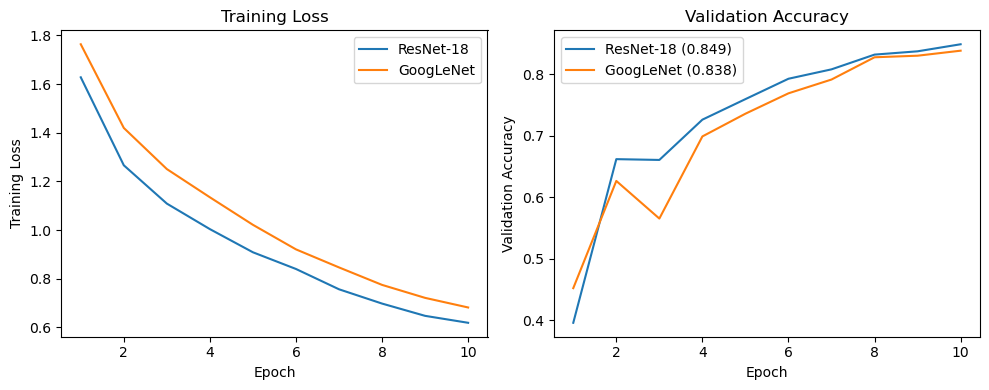

In [9]:
def plot_histories(histories):
    plt.figure(figsize=(10, 4))

    # Left panel: how quickly each model fits the training data.
    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        epochs = range(1, len(history["training_loss"]) + 1)
        plt.plot(epochs, history["training_loss"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss")
    plt.legend()

    # Right panel: how well each model generalizes to validation data.
    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        epochs = range(1, len(history["validation_accuracy"]) + 1)
        best = max(history["validation_accuracy"])
        plt.plot(epochs, history["validation_accuracy"], label=f"{name} ({best:.3f})")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_histories({
    "ResNet-18": resnet18_history,
    "GoogLeNet": googlenet_history,
})


## Validation Report

A single accuracy number is useful, but supervised classification work usually needs class-level error analysis. The report and confusion matrix show which labels are being confused.


ResNet-18 validation accuracy: 0.8487
              precision    recall  f1-score   support

   n01440764       0.92      0.89      0.90       387
   n02102040       0.92      0.93      0.92       395
   n02979186       0.81      0.87      0.84       357
   n03000684       0.69      0.76      0.73       386
   n03028079       0.92      0.86      0.89       409
   n03394916       0.85      0.82      0.83       394
   n03417042       0.88      0.86      0.87       389
   n03425413       0.82      0.78      0.80       419
   n03445777       0.83      0.82      0.83       399
   n03888257       0.86      0.90      0.88       390

    accuracy                           0.85      3925
   macro avg       0.85      0.85      0.85      3925
weighted avg       0.85      0.85      0.85      3925



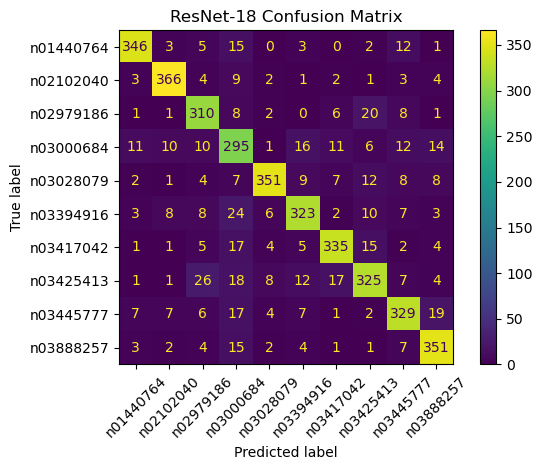

In [10]:
@torch.no_grad()
def predict_labels(model, data_loader):
    model = model.to(device)
    model.eval()
    all_predictions = []
    all_labels = []

    # Collect predictions batch by batch so the whole validation set is evaluated.
    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        logits = logits_from_model_output(model(images))
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.append(predictions)
        all_labels.append(labels.cpu())

    return torch.cat(all_predictions), torch.cat(all_labels)


predicted_labels, true_labels = predict_labels(resnet18_model, validation_dataloader)
accuracy = (predicted_labels == true_labels).float().mean().item()
print(f"ResNet-18 validation accuracy: {accuracy:.4f}")

# Show richer class-level diagnostics when scikit-learn is installed.
if SKLEARN_AVAILABLE:
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    matrix = confusion_matrix(true_labels, predicted_labels)
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(xticks_rotation=45)
    plt.title("ResNet-18 Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Install scikit-learn to show a classification report and confusion matrix.")


## Transfer Learning

Transfer learning starts from a model trained on a large source dataset, usually ImageNet, and adapts it to a smaller target dataset.

Two common supervised workflows are:

1. Feature extraction: freeze the convolutional backbone and train only a new classifier head.
2. Fine-tuning: unfreeze some or all of the backbone and train with a smaller learning rate.

Feature extraction is faster and safer when data is limited. Fine-tuning can perform better when the target dataset is large enough and close enough to the pretrained domain.


In [11]:
# Freezing and unfreezing is controlled through requires_grad.
def set_trainable(model, trainable):
    # Freezing means gradients are not computed for these parameters.
    for parameter in model.parameters():
        parameter.requires_grad = trainable


# Feature extraction freezes the pretrained backbone and trains a new head.
def build_feature_extractor(model_name, number_of_classes):
    model = build_torchvision_classifier(
        model_name,
        number_of_classes,
        pretrained=True,
    )
    set_trainable(model, False)
    model = replace_classifier(model, number_of_classes)
    return model


feature_extractor = build_feature_extractor("resnet18", number_of_classes)
trainable_parameters = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in feature_extractor.parameters())
print(f"Trainable parameters: {trainable_parameters:,} / {total_parameters:,}")

feature_extractor, feature_history, feature_best_accuracy = train_classifier(
    feature_extractor,
    "best_resnet18_feature_extractor.pt",
    number_of_epochs=5,
    learning_rate=1e-3,
    weight_decay=1e-4,
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/rwhite/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s] 


Trainable parameters: 5,130 / 11,181,642
Epoch 001 | Training Loss: 0.5902 | Validation Loss: 0.4096 | Validation Accuracy: 0.9801 | LR: 0.000905
Epoch 002 | Training Loss: 0.4209 | Validation Loss: 0.4020 | Validation Accuracy: 0.9819 | LR: 0.000655
Epoch 003 | Training Loss: 0.4129 | Validation Loss: 0.3960 | Validation Accuracy: 0.9852 | LR: 0.000345
Epoch 004 | Training Loss: 0.4023 | Validation Loss: 0.3900 | Validation Accuracy: 0.9868 | LR: 0.000095
Epoch 005 | Training Loss: 0.3990 | Validation Loss: 0.3899 | Validation Accuracy: 0.9860 | LR: 0.000000
Best Validation Accuracy: 0.9868


In [12]:
# Fine-tuning unfreezes only the last residual stage and classifier.
def unfreeze_last_resnet_stage(model):
    """Unfreeze the final ResNet block and classifier head."""
    set_trainable(model, False)
    for parameter in model.layer4.parameters():
        parameter.requires_grad = True
    for parameter in model.fc.parameters():
        parameter.requires_grad = True
    return model


fine_tune_model = build_torchvision_classifier(
    "resnet18",
    number_of_classes,
    pretrained=True,
)
fine_tune_model = unfreeze_last_resnet_stage(fine_tune_model)

trainable_parameters = sum(p.numel() for p in fine_tune_model.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in fine_tune_model.parameters())
print(f"Trainable parameters: {trainable_parameters:,} / {total_parameters:,}")

fine_tune_model, fine_tune_history, fine_tune_best_accuracy = train_classifier(
    fine_tune_model,
    "best_resnet18_fine_tuned.pt",
    number_of_epochs=5,
    learning_rate=1e-4,
    weight_decay=1e-4,
)


Trainable parameters: 8,398,858 / 11,181,642
Epoch 001 | Training Loss: 0.4901 | Validation Loss: 0.3882 | Validation Accuracy: 0.9766 | LR: 0.000090
Epoch 002 | Training Loss: 0.3651 | Validation Loss: 0.3758 | Validation Accuracy: 0.9783 | LR: 0.000065
Epoch 003 | Training Loss: 0.3353 | Validation Loss: 0.3674 | Validation Accuracy: 0.9806 | LR: 0.000035
Epoch 004 | Training Loss: 0.3193 | Validation Loss: 0.3599 | Validation Accuracy: 0.9811 | LR: 0.000010
Epoch 005 | Training Loss: 0.3126 | Validation Loss: 0.3573 | Validation Accuracy: 0.9804 | LR: 0.000000
Best Validation Accuracy: 0.9811


## Modern CNN Classifiers

ResNet and Inception are historically central, but they are not the end of the CNN story. These CNN families are still useful for supervised image classification:

- ResNeXt: a ResNet variant that adds grouped convolutions and the idea of cardinality.
- DenseNet: connects each layer to many later layers, encouraging feature reuse.
- EfficientNet and EfficientNetV2: scale depth, width, and resolution together for strong accuracy/compute tradeoffs.
- MobileNetV3 and ShuffleNetV2: lightweight CNNs for phones, embedded systems, and edge inference.
- RegNet: a family of CNNs designed by systematic architecture search and simple scaling rules.
- ConvNeXt: a modernized pure CNN inspired by transformer-era training and design choices, while remaining convolutional.
- Squeeze-and-Excitation style channel attention: often added to CNN backbones to recalibrate channel importance.

The experiments below train several of these CNN classifiers on the same Imagenette split. Keeping the dataset, transforms, optimizer family, and epoch budget fixed makes the comparison easier to interpret.

### Key Architecture Features

**ResNeXt** keeps the residual-block idea from ResNet, but splits some convolutions into multiple grouped paths. Students can think of this as adding several parallel transformations inside a residual block. The important new hyperparameter is *cardinality*: the number of groups or paths.

**DenseNet** connects each layer to later layers by concatenating feature maps. Instead of only passing the newest representation forward, DenseNet reuses earlier features directly. This encourages feature reuse and can reduce the number of parameters compared with similarly deep plain CNNs.

**EfficientNet** uses mobile inverted bottleneck blocks, depthwise separable convolutions, and squeeze-and-excitation channel attention. Its central idea is compound scaling: when the model gets larger, depth, width, and image resolution are scaled together rather than one at a time.

**MobileNetV3** is designed for efficient inference. It relies heavily on depthwise separable convolutions, inverted bottlenecks, squeeze-and-excitation, and mobile-friendly activation functions. It is a strong example of designing for deployment constraints, not just maximum accuracy.

**RegNet** is a family of CNNs built from simple, repeated residual-style stages. The main idea is not a new layer type, but a systematic rule for choosing widths and depths. This makes the architecture easier to scale and compare than hand-designed one-off networks.

**ConvNeXt** is a pure CNN that modernizes the ResNet recipe. It uses ideas such as larger depthwise convolution kernels, fewer activation functions, inverted bottleneck-style blocks, layer normalization, and strong modern training practices. It is useful because it shows that CNNs can still be competitive when the design is updated carefully.


In [13]:
def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


# These are notable CNN families available directly through torchvision.
modern_cnn_names = [
    "resnet18",
    "resnext50_32x4d",
    "densenet121",
    "efficientnet_b0",
    "mobilenet_v3_large",
    "regnet_y_400mf",
    "convnext_tiny",
]

print(f"{'Model':<22} {'Trainable Parameters':>22}")
print("-" * 46)
for model_name in modern_cnn_names:
    model = build_torchvision_classifier(model_name, number_of_classes, pretrained=False)
    print(f"{model_name:<22} {count_trainable_parameters(model):>22,}")


Model                    Trainable Parameters
----------------------------------------------
resnet18                           11,181,642
resnext50_32x4d                    23,000,394
densenet121                         6,964,106
efficientnet_b0                     4,020,358
mobilenet_v3_large                  4,214,842
regnet_y_400mf                      3,907,554
convnext_tiny                      27,827,818


## Training Modern CNNs from Scratch

The following code trains EfficientNet-B0, ConvNeXt-Tiny, ResNeXt-50, DenseNet-121, MobileNetV3-Large, and RegNetY-400MF on Imagenette. These are real training cells, not pseudocode.

Transfer learning is usually the practical baseline, but training from scratch is still useful for understanding architecture behavior. These runs can be expensive. If the first pass is slow, reduce `MODERN_SCRATCH_EPOCHS`; if the curves are still improving, increase it.


In [14]:
# Increase this for real training; decrease it for quick classroom demos.
MODERN_SCRATCH_EPOCHS = 10

modern_scratch_models = {
    "EfficientNet-B0": "efficientnet_b0",
    "ConvNeXt-Tiny": "convnext_tiny",
    "ResNeXt-50 32x4d": "resnext50_32x4d",
    "DenseNet-121": "densenet121",
    "MobileNetV3-Large": "mobilenet_v3_large",
    "RegNetY-400MF": "regnet_y_400mf",
}

modern_scratch_histories = {}
modern_scratch_best_accuracies = {}
modern_scratch_trained_models = {}

# Train each architecture under the same optimization settings.
for display_name, model_name in modern_scratch_models.items():
    print(f"\nTraining {display_name} from scratch")
    model = build_torchvision_classifier(
        model_name,
        number_of_classes,
        pretrained=False,
    )

    model, history, best_accuracy = train_classifier(
        model,
        f"best_{model_name}_from_scratch.pt",
        number_of_epochs=MODERN_SCRATCH_EPOCHS,
        learning_rate=3e-4,
        weight_decay=1e-4,
    )

    modern_scratch_trained_models[display_name] = model
    modern_scratch_histories[display_name] = history
    modern_scratch_best_accuracies[display_name] = best_accuracy

print("\nModern CNN from-scratch results")
print(f"{'Model':<22} {'Best Val Acc':>14}")
print("-" * 38)
for display_name, best_accuracy in modern_scratch_best_accuracies.items():
    print(f"{display_name:<22} {best_accuracy:>14.4f}")



Training EfficientNet-B0 from scratch
Epoch 001 | Training Loss: 1.9551 | Validation Loss: 1.6916 | Validation Accuracy: 0.4334 | LR: 0.000293
Epoch 002 | Training Loss: 1.5635 | Validation Loss: 1.3356 | Validation Accuracy: 0.5941 | LR: 0.000271
Epoch 003 | Training Loss: 1.3464 | Validation Loss: 1.2204 | Validation Accuracy: 0.6550 | LR: 0.000238
Epoch 004 | Training Loss: 1.1974 | Validation Loss: 1.1212 | Validation Accuracy: 0.6869 | LR: 0.000196
Epoch 005 | Training Loss: 1.0932 | Validation Loss: 0.9757 | Validation Accuracy: 0.7422 | LR: 0.000150
Epoch 006 | Training Loss: 1.0001 | Validation Loss: 0.9367 | Validation Accuracy: 0.7618 | LR: 0.000104
Epoch 007 | Training Loss: 0.9365 | Validation Loss: 0.8765 | Validation Accuracy: 0.7783 | LR: 0.000062
Epoch 008 | Training Loss: 0.8679 | Validation Loss: 0.8621 | Validation Accuracy: 0.7776 | LR: 0.000029
Epoch 009 | Training Loss: 0.8346 | Validation Loss: 0.8310 | Validation Accuracy: 0.7972 | LR: 0.000007
Epoch 010 | Trai

## Transfer Learning with Modern CNNs

Modern CNNs are often strongest when they start from ImageNet-pretrained weights. The cells below train several pretrained CNNs as feature extractors. Only each model's classifier head is trainable, so these runs are usually much cheaper than training the whole network from scratch.

After comparing feature-extraction results, a common next step is to fine-tune the best one by unfreezing its last stage and lowering the learning rate.


In [15]:
# Feature extraction usually needs fewer epochs than training from scratch.
MODERN_TRANSFER_EPOCHS = 5

modern_transfer_models = {
    "EfficientNet-B0": "efficientnet_b0",
    "ConvNeXt-Tiny": "convnext_tiny",
    "ResNeXt-50 32x4d": "resnext50_32x4d",
    "DenseNet-121": "densenet121",
    "MobileNetV3-Large": "mobilenet_v3_large",
    "RegNetY-400MF": "regnet_y_400mf",
}

modern_transfer_histories = {}
modern_transfer_best_accuracies = {}
modern_transfer_trained_models = {}

# Train only the classifier head for each pretrained architecture.
for display_name, model_name in modern_transfer_models.items():
    print(f"\nTraining {display_name} as a pretrained feature extractor")
    model = build_feature_extractor(model_name, number_of_classes)

    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_parameters = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_parameters:,} / {total_parameters:,}")

    model, history, best_accuracy = train_classifier(
        model,
        f"best_{model_name}_feature_extractor.pt",
        number_of_epochs=MODERN_TRANSFER_EPOCHS,
        learning_rate=1e-3,
        weight_decay=1e-4,
    )

    modern_transfer_trained_models[display_name] = model
    modern_transfer_histories[display_name] = history
    modern_transfer_best_accuracies[display_name] = best_accuracy

print("\nModern CNN transfer-learning results")
print(f"{'Model':<22} {'Best Val Acc':>14}")
print("-" * 38)
for display_name, best_accuracy in modern_transfer_best_accuracies.items():
    print(f"{display_name:<22} {best_accuracy:>14.4f}")



Training EfficientNet-B0 as a pretrained feature extractor
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/rwhite/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 104MB/s] 


Trainable parameters: 12,810 / 4,020,358
Epoch 001 | Training Loss: 0.5959 | Validation Loss: 0.3614 | Validation Accuracy: 0.9865 | LR: 0.000905
Epoch 002 | Training Loss: 0.4222 | Validation Loss: 0.3585 | Validation Accuracy: 0.9898 | LR: 0.000655
Epoch 003 | Training Loss: 0.4063 | Validation Loss: 0.3570 | Validation Accuracy: 0.9883 | LR: 0.000345
Epoch 004 | Training Loss: 0.4015 | Validation Loss: 0.3576 | Validation Accuracy: 0.9880 | LR: 0.000095
Epoch 005 | Training Loss: 0.3971 | Validation Loss: 0.3563 | Validation Accuracy: 0.9883 | LR: 0.000000
Best Validation Accuracy: 0.9898

Training ConvNeXt-Tiny as a pretrained feature extractor
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /home/rwhite/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 101MB/s]  


Trainable parameters: 7,690 / 27,827,818
Epoch 001 | Training Loss: 0.3944 | Validation Loss: 0.2966 | Validation Accuracy: 0.9997 | LR: 0.000905
Epoch 002 | Training Loss: 0.2965 | Validation Loss: 0.2953 | Validation Accuracy: 0.9997 | LR: 0.000655
Epoch 003 | Training Loss: 0.2950 | Validation Loss: 0.2951 | Validation Accuracy: 0.9997 | LR: 0.000345
Epoch 004 | Training Loss: 0.2936 | Validation Loss: 0.2943 | Validation Accuracy: 0.9997 | LR: 0.000095
Epoch 005 | Training Loss: 0.2926 | Validation Loss: 0.2941 | Validation Accuracy: 0.9997 | LR: 0.000000
Best Validation Accuracy: 0.9997

Training ResNeXt-50 32x4d as a pretrained feature extractor
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /home/rwhite/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


...

Trainable parameters: 10,250 / 6,964,106
Epoch 001 | Training Loss: 0.5355 | Validation Loss: 0.3727 | Validation Accuracy: 0.9896 | LR: 0.000905
Epoch 002 | Training Loss: 0.3868 | Validation Loss: 0.3641 | Validation Accuracy: 0.9906 | LR: 0.000655
Epoch 003 | Training Loss: 0.3751 | Validation Loss: 0.3597 | Validation Accuracy: 0.9896 | LR: 0.000345
Epoch 004 | Training Loss: 0.3645 | Validation Loss: 0.3573 | Validation Accuracy: 0.9916 | LR: 0.000095
Epoch 005 | Training Loss: 0.3624 | Validation Loss: 0.3557 | Validation Accuracy: 0.9911 | LR: 0.000000
Best Validation Accuracy: 0.9916

Training MobileNetV3-Large as a pretrained feature extractor
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/rwhite/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 46.6MB/s]


Trainable parameters: 12,810 / 4,214,842
Epoch 001 | Training Loss: 0.5506 | Validation Loss: 0.3492 | Validation Accuracy: 0.9896 | LR: 0.000905
Epoch 002 | Training Loss: 0.3786 | Validation Loss: 0.3473 | Validation Accuracy: 0.9898 | LR: 0.000655
Epoch 003 | Training Loss: 0.3678 | Validation Loss: 0.3458 | Validation Accuracy: 0.9898 | LR: 0.000345
Epoch 004 | Training Loss: 0.3642 | Validation Loss: 0.3435 | Validation Accuracy: 0.9903 | LR: 0.000095
Epoch 005 | Training Loss: 0.3611 | Validation Loss: 0.3440 | Validation Accuracy: 0.9903 | LR: 0.000000
Best Validation Accuracy: 0.9903

Training RegNetY-400MF as a pretrained feature extractor
Downloading: "https://download.pytorch.org/models/regnet_y_400mf-e6988f5f.pth" to /home/rwhite/.cache/torch/hub/checkpoints/regnet_y_400mf-e6988f5f.pth


100%|██████████| 16.8M/16.8M [00:00<00:00, 55.6MB/s]


Trainable parameters: 4,410 / 3,907,554
Epoch 001 | Training Loss: 0.6391 | Validation Loss: 0.3908 | Validation Accuracy: 0.9799 | LR: 0.000905
Epoch 002 | Training Loss: 0.3965 | Validation Loss: 0.3608 | Validation Accuracy: 0.9865 | LR: 0.000655
Epoch 003 | Training Loss: 0.3946 | Validation Loss: 0.3631 | Validation Accuracy: 0.9868 | LR: 0.000345
Epoch 004 | Training Loss: 0.3813 | Validation Loss: 0.3627 | Validation Accuracy: 0.9865 | LR: 0.000095
Epoch 005 | Training Loss: 0.3772 | Validation Loss: 0.3585 | Validation Accuracy: 0.9878 | LR: 0.000000
Best Validation Accuracy: 0.9878

Modern CNN transfer-learning results
Model                    Best Val Acc
--------------------------------------
EfficientNet-B0                0.9898
ConvNeXt-Tiny                  0.9997
ResNeXt-50 32x4d               0.9972
DenseNet-121                   0.9916
MobileNetV3-Large              0.9903
RegNetY-400MF                  0.9878


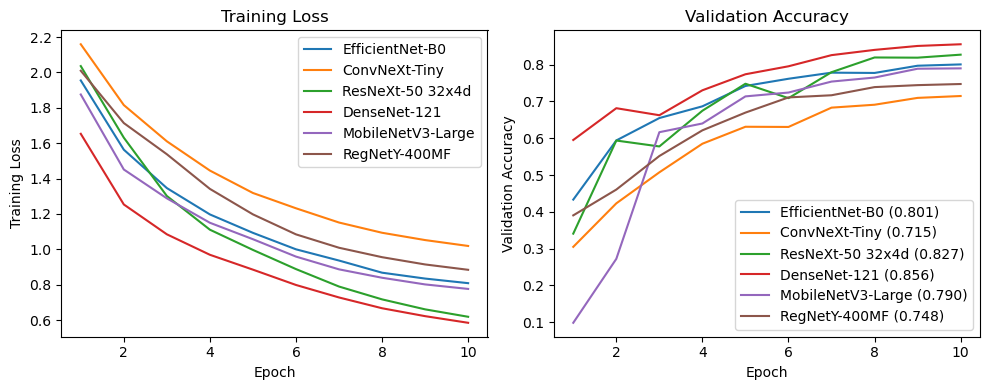

Model                    Scratch Best  Transfer Best
------------------------------------------------------
EfficientNet-B0                0.8008         0.9898
ConvNeXt-Tiny                  0.7149         0.9997
ResNeXt-50 32x4d               0.8273         0.9972
DenseNet-121                   0.8555         0.9916
MobileNetV3-Large              0.7901         0.9903
RegNetY-400MF                  0.7475         0.9878


In [16]:
# Visualize from-scratch training behavior before comparing final scores.
plot_histories(modern_scratch_histories)

print(f"{'Model':<22} {'Scratch Best':>14} {'Transfer Best':>14}")
print("-" * 54)
for display_name in modern_scratch_models:
    scratch_best = modern_scratch_best_accuracies.get(display_name, float('nan'))
    transfer_best = modern_transfer_best_accuracies.get(display_name, float('nan'))
    print(f"{display_name:<22} {scratch_best:>14.4f} {transfer_best:>14.4f}")


## Ensembling: Soft Voting

An ensemble combines multiple classifiers. For neural classifiers, a common approach is soft voting: average the logits or probabilities from several models, then choose the class with the largest average score.

Ensembles help when individual models are strong but make different mistakes. Training five copies of the same architecture with different random seeds can help, but mixing architectures often increases diversity even more.


In [17]:
@torch.no_grad()
# Each model contributes logits for every validation example.
def collect_logits(model, data_loader):
    model = model.to(device)
    model.eval()
    logits_batches = []
    labels_batches = []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        logits = logits_from_model_output(model(images)).cpu()
        logits_batches.append(logits)
        labels_batches.append(labels.cpu())

    return torch.cat(logits_batches), torch.cat(labels_batches)


# Soft voting averages logits before choosing the final predicted class.
def soft_vote_ensemble(models_to_ensemble, data_loader):
    # Each model votes with its raw class scores; averaging logits is soft voting.
    logits_list = []
    true_labels = None

    for model in models_to_ensemble:
        logits, labels = collect_logits(model, data_loader)
        logits_list.append(logits)
        if true_labels is None:
            true_labels = labels

    average_logits = torch.stack(logits_list).mean(dim=0)
    predictions = average_logits.argmax(dim=1)
    accuracy = (predictions == true_labels).float().mean().item()
    return predictions, true_labels, accuracy


ensemble_predictions, ensemble_true_labels, ensemble_accuracy = soft_vote_ensemble(
    [resnet18_model, googlenet_model],
    validation_dataloader,
)
print(f"Soft-voting ensemble accuracy: {ensemble_accuracy:.4f}")


Soft-voting ensemble accuracy: 0.8627


## Training an Ensemble from Different Seeds

The cell below is an experiment template. It trains several ResNet-18 models from scratch using different random seeds, then ensembles them.

This is computationally expensive, so reduce `number_of_epochs` while testing the notebook and increase it for a real run.


In [18]:
# Different seeds produce related but not identical ResNet-18 models.
def train_seeded_resnet_ensemble(seeds=(0, 1, 2), number_of_epochs=5):
    # Different seeds give different initial weights and data-shuffle orders.
    ensemble_models = []
    ensemble_histories = {}

    for seed in seeds:
        torch.manual_seed(seed)
        random.seed(seed)
        model = build_torchvision_classifier(
            "resnet18",
            number_of_classes,
            pretrained=False,
        )
        model, history, best_accuracy = train_classifier(
            model,
            f"best_resnet18_seed_{seed}.pt",
            number_of_epochs=number_of_epochs,
            learning_rate=3e-4,
            weight_decay=1e-4,
        )
        ensemble_models.append(model)
        ensemble_histories[f"seed {seed}"] = history
        print(f"Seed {seed} best validation accuracy: {best_accuracy:.4f}")

    predictions, labels, accuracy = soft_vote_ensemble(ensemble_models, validation_dataloader)
    print(f"Seeded ResNet-18 ensemble accuracy: {accuracy:.4f}")
    return ensemble_models, ensemble_histories, accuracy


seeded_models, seeded_histories, seeded_ensemble_accuracy = train_seeded_resnet_ensemble(
    seeds=(0, 1, 2),
    number_of_epochs=5,
)


Epoch 001 | Training Loss: 1.6308 | Validation Loss: 1.9172 | Validation Accuracy: 0.4930 | LR: 0.000271
Epoch 002 | Training Loss: 1.2578 | Validation Loss: 1.2487 | Validation Accuracy: 0.6336 | LR: 0.000196
Epoch 003 | Training Loss: 1.0651 | Validation Loss: 1.1236 | Validation Accuracy: 0.6907 | LR: 0.000104
Epoch 004 | Training Loss: 0.9172 | Validation Loss: 0.9655 | Validation Accuracy: 0.7391 | LR: 0.000029
Epoch 005 | Training Loss: 0.8153 | Validation Loss: 0.8351 | Validation Accuracy: 0.8013 | LR: 0.000000
Best Validation Accuracy: 0.8013
Seed 0 best validation accuracy: 0.8013
Epoch 001 | Training Loss: 1.6457 | Validation Loss: 1.3454 | Validation Accuracy: 0.6071 | LR: 0.000271
Epoch 002 | Training Loss: 1.2514 | Validation Loss: 1.2877 | Validation Accuracy: 0.6237 | LR: 0.000196
Epoch 003 | Training Loss: 1.0592 | Validation Loss: 1.1827 | Validation Accuracy: 0.6690 | LR: 0.000104
Epoch 004 | Training Loss: 0.9136 | Validation Loss: 0.9660 | Validation Accuracy: 0.74

## Snapshot Ensembles

A snapshot ensemble trains one model with a cyclic learning-rate schedule. At the end of each cycle, the model has hopefully settled into a useful region of parameter space. We save that state as a snapshot, restart the learning rate, and continue training.

The benefit is cost: one long training run can produce several ensemble members. The risk is diversity: snapshots from one model may be less different than independently trained models.


In [19]:
# Snapshot ensembles save one model at the end of each learning-rate cycle.
def train_snapshot_ensemble(
    model,
    snapshot_directory,
    *,
    number_of_cycles=3,
    epochs_per_cycle=5,
    max_learning_rate=3e-4,
    min_learning_rate=1e-6,
    weight_decay=1e-4,
):
    snapshot_directory = Path(snapshot_directory)
    snapshot_directory.mkdir(parents=True, exist_ok=True)

    model = model.to(device)
    loss_function = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=max_learning_rate,
        weight_decay=weight_decay,
    )
    # Warm restarts repeatedly lower the learning rate, then jump it back up.
    # Warm restarts periodically raise the learning rate to explore new solutions.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=epochs_per_cycle,
        T_mult=1,
        eta_min=min_learning_rate,
    )

    snapshot_paths = []
    total_epochs = number_of_cycles * epochs_per_cycle

    for epoch_index in range(total_epochs):
        model.train()
        total_training_loss = 0.0

        for images, labels in training_dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = logits_from_model_output(model(images))
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_training_loss += loss.item() * images.size(0)

        scheduler.step()
        average_training_loss = total_training_loss / len(training_dataset)

        cycle_position = (epoch_index + 1) % epochs_per_cycle
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch_index + 1:03d}/{total_epochs:03d} | "
            f"Training Loss: {average_training_loss:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        if cycle_position == 0:
            snapshot_path = snapshot_directory / f"snapshot_epoch_{epoch_index + 1:03d}.pt"
            torch.save({"model_state": deepcopy(model.state_dict())}, snapshot_path)
            snapshot_paths.append(snapshot_path)
            print(f"Saved snapshot: {snapshot_path}")

    return snapshot_paths


def load_snapshots(model_name, snapshot_paths):
    loaded_models = []
    for path in snapshot_paths:
        model = build_torchvision_classifier(model_name, number_of_classes, pretrained=False)
        checkpoint = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state"])
        loaded_models.append(model)
    return loaded_models


snapshot_base_model = build_torchvision_classifier("resnet18", number_of_classes, pretrained=False)
snapshot_paths = train_snapshot_ensemble(
    snapshot_base_model,
    "snapshots_resnet18",
    number_of_cycles=3,
    epochs_per_cycle=5,
)
snapshot_models = load_snapshots("resnet18", snapshot_paths)
_, _, snapshot_ensemble_accuracy = soft_vote_ensemble(snapshot_models, validation_dataloader)
print(f"Snapshot ensemble accuracy: {snapshot_ensemble_accuracy:.4f}")


Epoch 001/015 | Training Loss: 1.6192 | LR: 0.000271
Epoch 002/015 | Training Loss: 1.2281 | LR: 0.000197
Epoch 003/015 | Training Loss: 1.0516 | LR: 0.000104
Epoch 004/015 | Training Loss: 0.9123 | LR: 0.000030
Epoch 005/015 | Training Loss: 0.8028 | LR: 0.000300
Saved snapshot: snapshots_resnet18/snapshot_epoch_005.pt
Epoch 006/015 | Training Loss: 1.0163 | LR: 0.000271
Epoch 007/015 | Training Loss: 0.9290 | LR: 0.000197
Epoch 008/015 | Training Loss: 0.8398 | LR: 0.000104
Epoch 009/015 | Training Loss: 0.7381 | LR: 0.000030
Epoch 010/015 | Training Loss: 0.6519 | LR: 0.000300
Saved snapshot: snapshots_resnet18/snapshot_epoch_010.pt
Epoch 011/015 | Training Loss: 0.8350 | LR: 0.000271
Epoch 012/015 | Training Loss: 0.7963 | LR: 0.000197
Epoch 013/015 | Training Loss: 0.7152 | LR: 0.000104
Epoch 014/015 | Training Loss: 0.6327 | LR: 0.000030
Epoch 015/015 | Training Loss: 0.5575 | LR: 0.000300
Saved snapshot: snapshots_resnet18/snapshot_epoch_015.pt
Snapshot ensemble accuracy: 0.8464

## Takeaways

Inception improved CNN efficiency by letting a layer combine multiple spatial scales. ResNet made very deep CNN optimization practical by adding shortcut connections. Modern CNNs such as EfficientNet, ConvNeXt, ResNeXt, DenseNet, MobileNetV3, and RegNet explore different tradeoffs between accuracy, parameter count, and compute. Transfer learning is often the strongest practical baseline for small or medium image datasets. Ensembling improves supervised predictions when models are already strong and make different mistakes.

When deciding what to train first:

1. Start with a pretrained ResNet, EfficientNet, or ConvNeXt baseline.
2. Use the same train/validation split and preprocessing for fair comparisons.
3. Fine-tune only the head first, then unfreeze deeper layers if validation performance plateaus.
4. Compare accuracy, class-level errors, parameter count, and training cost.
5. Ensemble only after individual models are already reasonably strong.
